# Event-Aware Uplift Modeling for Promotion Decisions in E-Commerce

### From Sequential Customer Behavior to Incremental Promotion Effect

**Objective**

This project develops an event-aware uplift modeling pipeline to estimate
whether a promotion is expected to generate additional purchase behavior
for individual customer-product decision points.

Unlike conventional purchase propensity modeling, the main target is the
incremental treatment effect:

\[
\tau(X) = E[Y(1)-Y(0)\mid X]
\]

The analysis uses real-world e-commerce event data over a five-month period.

In [1]:
# ============================================================
# 1.1 INSTALL REQUIRED LIBRARIES
# ============================================================

%pip install -q kagglehub lightgbm shap tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# 1.2 IMPORT LIBRARIES
# ============================================================

import os
import warnings
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Optional libraries
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM unavailable.")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP unavailable.")

try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    HAS_TF = True
except ImportError:
    HAS_TF = False
    print("TensorFlow unavailable.")

# Reproducibility
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

if HAS_TF:
    tf.random.set_seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 2. Dataset Loading

The analysis uses the REES46 multi-category e-commerce event dataset.

Five monthly files are combined to construct a continuous observation period
from October 2019 to February 2020.

In [3]:
# ============================================================
# 2.1 DOWNLOAD DATASET
# ============================================================

import kagglehub

path = kagglehub.dataset_download(
    "mkechinov/ecommerce-events-history-in-cosmetics-shop"
)

print("Dataset path:")
print(path)

Dataset path:
/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6


In [4]:
# ============================================================
# 2.2 INSPECT AVAILABLE FILES
# ============================================================

available_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            available_files.append(
                os.path.join(root, file)
            )

for f in available_files:
    print(f)

/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6/2020-Jan.csv
/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6/2019-Dec.csv
/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6/2020-Feb.csv
/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6/2019-Nov.csv
/Users/Vicky/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6/2019-Oct.csv


In [5]:
# ============================================================
# 2.3 LOAD FIVE MONTHS
# ============================================================

MONTHS = [
    "2019-Oct.csv",
    "2019-Nov.csv",
    "2019-Dec.csv",
    "2020-Jan.csv",
    "2020-Feb.csv"
]

USECOLS = [
    "event_time",
    "event_type",
    "product_id",
    "category_id",
    "category_code",
    "brand",
    "price",
    "user_id",
    "user_session"
]

DTYPES = {
    "event_type": "category",
    "product_id": "int32",
    "category_id": "float32",
    "category_code": "string",
    "brand": "string",
    "price": "float32",
    "user_id": "int64",
    "user_session": "string"
}

data_parts = []

for month in MONTHS:

    file_path = os.path.join(path, month)

    print(f"Loading {month}...")

    temp = pd.read_csv(
        file_path,
        usecols=USECOLS,
        dtype=DTYPES
    )

    data_parts.append(temp)

df = pd.concat(
    data_parts,
    ignore_index=True
)

df["event_time"] = pd.to_datetime(
    df["event_time"],
    errors="coerce"
)

df = (
    df
    .sort_values("event_time")
    .reset_index(drop=True)
)

print("\n==============================")
print("DATASET LOADED")
print("==============================")

print("Rows:", f"{len(df):,}")
print("Columns:", len(df.columns))
print("Start:", df["event_time"].min())
print("End:", df["event_time"].max())

display(df.head())

Loading 2019-Oct.csv...
Loading 2019-Nov.csv...
Loading 2019-Dec.csv...
Loading 2020-Jan.csv...
Loading 2020-Feb.csv...

DATASET LOADED
Rows: 20,692,840
Columns: 9
Start: 2019-10-01 00:00:00+00:00
End: 2020-02-29 23:59:59+00:00


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00+00:00,cart,5773203,1.487580e+18,<NA>,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
1,2019-10-01 00:00:03+00:00,cart,5773353,1.487580e+18,<NA>,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
2,2019-10-01 00:00:07+00:00,cart,5881589,2.151191e+18,<NA>,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
3,2019-10-01 00:00:07+00:00,cart,5723490,1.487580e+18,<NA>,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
4,2019-10-01 00:00:15+00:00,cart,5881449,1.487580e+18,<NA>,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9


# 3. Data Understanding

Before preprocessing, the raw event log is inspected to verify:

- available variables
- event types
- missing values
- timestamp coverage
- user and product coverage

This step does not create causal labels or treatment variables.

In [6]:
# ============================================================
# 3.1 BASIC INFORMATION
# ============================================================

print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== DATA TYPES ===")
print(df.dtypes)

=== SHAPE ===
(20692840, 9)

=== COLUMNS ===
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

=== DATA TYPES ===
event_time       datetime64[us, UTC]
event_type                  category
product_id                     int32
category_id                  float32
category_code                 string
brand                         string
price                        float32
user_id                        int64
user_session                  string
dtype: object


In [7]:
# ============================================================
# 3.2 MISSING VALUES
# ============================================================

missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing.to_frame("missing_count")
)

,missing_count
category_code,20339246
brand,8757117
user_session,4598
event_time,0
event_type,0
product_id,0
category_id,0
price,0
user_id,0


In [8]:
# ============================================================
# 3.3 EVENT DISTRIBUTION
# ============================================================

event_counts = (
    df["event_type"]
    .value_counts()
)

display(
    event_counts.to_frame("count")
)

print(
    "Event types:",
    df["event_type"].unique()
)

,count
event_type,
view,9657821
cart,5768333
remove_from_cart,3979679
purchase,1287007


Event types: ['cart', 'view', 'remove_from_cart', 'purchase']
Categories (4, str): ['cart', 'purchase', 'remove_from_cart', 'view']


# 4. Configuration

All analytical parameters are centralized here.

Some parameters remain data-dependent and should be checked empirically
before the final model is locked, especially:

- treatment definition
- outcome window
- event-detection threshold
- sequence length
- uplift estimator

This follows the revised methodology.

In [9]:
# ============================================================
# 4.1 CONFIGURATION
# ============================================================

CONFIG = {

    # Data
    "months": MONTHS,

    # Columns
    "time": "event_time",
    "event": "event_type",
    "user": "user_id",
    "session": "user_session",
    "product": "product_id",
    "category": "category_id",
    "brand": "brand",
    "price": "price",

    # Event definitions
    "decision_event": "cart",
    "purchase_event": "purchase",

    # Session
    "session_gap_minutes": 30,

    # Outcome
    "outcome_window_minutes": 120,

    # Event discovery
    "mad_z_threshold": 2.5,

    # Sequence
    "max_sequence_length": 4,

    # GRU
    "embedding_dim": 8,
    "gru_units": 16,

    # Validation
    "validation_ratio": 0.20,
    "test_ratio": 0.20,
    "n_seeds": 5,

    # Treatment
    # Starting threshold only — validate empirically
    "discount_threshold": 0.05,

    # Policy
    "tau_threshold": 0.05,

    # Seed
    "seed": 42
}

print("Configuration loaded.")

Configuration loaded.


# 5. Stage 1 — Real-Data Preprocessing

The raw event log is cleaned without creating artificial behavioral or
causal labels.

The preprocessing includes:

1. column normalization
2. duplicate removal
3. timestamp conversion
4. numeric conversion
5. missing-value handling
6. invalid price removal
7. chronological sorting

In [10]:
# ============================================================
# 5.1 PREPROCESSING FUNCTION
# ============================================================

def preprocess_data(df):

    data = df.copy()

    # Normalize column names
    data.columns = (
        data.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    # Timestamp
    data["event_time"] = pd.to_datetime(
        data["event_time"],
        errors="coerce"
    )

    # Numeric
    data["price"] = pd.to_numeric(
        data["price"],
        errors="coerce"
    )

    # Remove duplicates
    before_dup = len(data)

    data = data.drop_duplicates(
        subset=[
            "user_id",
            "product_id",
            "event_type",
            "event_time"
        ]
    )

    print(
        "Duplicates removed:",
        before_dup - len(data)
    )

    # Required fields
    before_missing = len(data)

    data = data.dropna(
        subset=[
            "event_time",
            "user_id",
            "product_id",
            "price"
        ]
    )

    print(
        "Missing required rows removed:",
        before_missing - len(data)
    )

    # Valid price
    before_price = len(data)

    data = data[
        data["price"] > 0
    ]

    print(
        "Invalid price rows removed:",
        before_price - len(data)
    )

    # Sort
    data = (
        data
        .sort_values(
            ["user_id", "event_time"]
        )
        .reset_index(drop=True)
    )

    return data

In [11]:
# ============================================================
# 5.2 RUN PREPROCESSING
# ============================================================

df_clean = preprocess_data(df)

print("\nClean dataset:")
print(df_clean.shape)

display(df_clean.head())

Duplicates removed: 1120960
Missing required rows removed: 0
Invalid price rows removed: 82736

Clean dataset:
(19489144, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-01-14 16:15:21+00:00,view,5865526,1.487580e+18,<NA>,cnd,10.00,465496,8ad668e6-9567-4da9-b43b-250f12ecab5b
1,2020-01-14 16:25:35+00:00,view,5769989,1.487580e+18,<NA>,cnd,10.00,465496,d4b9b57f-237c-4427-80e1-b0073b0b0b6c
2,2020-01-14 16:27:31+00:00,view,5865524,1.487580e+18,<NA>,cnd,10.00,465496,d4b9b57f-237c-4427-80e1-b0073b0b0b6c
3,2019-11-04 15:28:57+00:00,view,5240,1.487580e+18,<NA>,runail,4.05,1120748,d0484d94-7ac1-44e8-a310-2360da11ad9d
4,2019-12-28 14:32:56+00:00,view,5881337,1.487580e+18,<NA>,fedua,25.40,1180452,a4818e6d-9069-4aa8-8731-572ac266283f


In [12]:
# ============================================================
# 5.3 POST-CLEANING CHECK
# ============================================================

print("Missing values:")
display(
    df_clean.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

print("\nEvents:")
display(
    df_clean["event_type"]
    .value_counts()
    .to_frame("count")
)

Missing values:


,missing
category_code,19147736
brand,8175804
user_session,4084
event_time,0
event_type,0
product_id,0
category_id,0
price,0
user_id,0



Events:


,count
event_type,
view,9618242
cart,5615605
remove_from_cart,2969354
purchase,1285943


# 6. Stage 2 — Data-Driven Temporal Event Discovery

Daily behavioral activity is aggregated into:

- total events
- active users
- purchase events

A composite activity score is standardized and converted into a robust
MAD-based anomaly score.

The event levels are therefore derived from observed activity rather than
manually assigning calendar events before seeing the data.

In [13]:
# ============================================================
# 6.1 DAILY ACTIVITY
# ============================================================

daily = (
    df_clean
    .assign(
        date=df_clean["event_time"].dt.floor("D")
    )
    .groupby("date")
    .agg(
        n_events=("user_id", "size"),
        n_users=("user_id", "nunique"),
        n_purchase=(
            "event_type",
            lambda x:
            (x == CONFIG["purchase_event"]).sum()
        )
    )
)

display(daily.head())

,n_events,n_users,n_purchase
date,,,
2019-10-01 00:00:00+00:00,134747,19219,8466
2019-10-02 00:00:00+00:00,190386,33844,9098
2019-10-03 00:00:00+00:00,118331,16299,8856
2019-10-04 00:00:00+00:00,109796,14723,7560
2019-10-05 00:00:00+00:00,100643,14984,5933


In [14]:
# ============================================================
# 6.2 ROBUST EVENT DETECTION
# ============================================================

z = (
    daily - daily.mean()
) / daily.std(ddof=0)

z = z.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

daily["A_d"] = z.mean(axis=1)

M = daily["A_d"].median()

MAD = (
    daily["A_d"] - M
).abs().median()

if MAD == 0:
    MAD = 1e-6

daily["Z_robust"] = (
    0.6745
    * (daily["A_d"] - M)
    / MAD
)

threshold = CONFIG["mad_z_threshold"]

daily["event_level"] = np.select(
    [
        daily["Z_robust"] >= threshold * 2.4,
        daily["Z_robust"] >= threshold * 1.6,
        daily["Z_robust"] >= threshold
    ],
    [
        3,
        2,
        1
    ],
    default=0
)

print("Event-level distribution:")

display(
    daily["event_level"]
    .value_counts()
    .sort_index()
    .to_frame("days")
)

Event-level distribution:


,days
event_level,
0,141
1,8
2,2
3,1


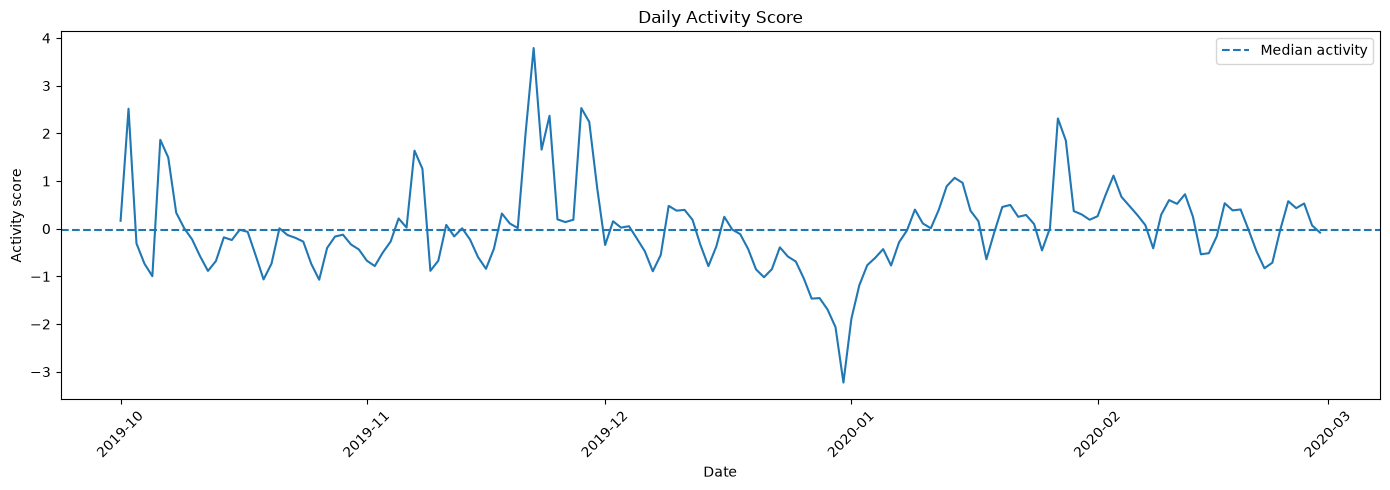

In [15]:
# ============================================================
# 6.3 VISUALIZE DAILY ACTIVITY
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    daily.index,
    daily["A_d"]
)

plt.axhline(
    M,
    linestyle="--",
    label="Median activity"
)

plt.title(
    "Daily Activity Score"
)

plt.xlabel("Date")
plt.ylabel("Activity score")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 6.4 MERGE EVENT CONTEXT INTO EVENT LOG 
# ============================================================

event_context = daily[["A_d", "Z_robust", "event_level"]].copy()

# Dùng context của NGÀY HÔM TRƯỚC, không dùng context của chính ngày hôm đó.
# -> decision point trong ngày D chỉ "biết" mức độ event tính đến hết ngày D-1.
event_context.index = event_context.index + pd.Timedelta(days=1)
event_context = event_context.rename(columns={
    "A_d": "A_d_lag1",
    "Z_robust": "Z_robust_lag1",
    "event_level": "event_level_lag1",
})

df_event = (
    df_clean
    .assign(date=df_clean["event_time"].dt.floor("D"))
    .merge(event_context, left_on="date", right_index=True, how="left")
    .fillna({"A_d_lag1": 0, "Z_robust_lag1": 0, "event_level_lag1": 0})
)

display(
    df_event[
        ["event_time", "event_type", "A_d_lag1", "Z_robust_lag1", "event_level_lag1"]
    ].head()
)

,event_time,event_type,A_d_lag1,Z_robust_lag1,event_level_lag1
0,2020-01-14 16:15:21+00:00,view,0.890908,1.451123,0.0
1,2020-01-14 16:25:35+00:00,view,0.890908,1.451123,0.0
2,2020-01-14 16:27:31+00:00,view,0.890908,1.451123,0.0
3,2019-11-04 15:28:57+00:00,view,-0.502530,-0.763580,0.0
4,2019-12-28 14:32:56+00:00,view,-1.466228,-2.295264,0.0


# 7. Stage 3 — Session Construction and Decision Points

Customer events are ordered chronologically.

A new session starts when inactivity exceeds 30 minutes.

The decision point is defined as an observed `cart` event.

For every decision point, only information available before or at the
decision point can be used as model input.

In [17]:
# ============================================================
# 7.1 BUILD SESSIONS
# ============================================================

df_session = (
    df_event
    .sort_values(
        ["user_id", "event_time"]
    )
    .copy()
)

df_session["gap_minutes"] = (
    df_session
    .groupby("user_id")["event_time"]
    .diff()
    .dt.total_seconds()
    / 60
)

df_session["new_session"] = (
    df_session["gap_minutes"].isna()
    |
    (
        df_session["gap_minutes"]
        > CONFIG["session_gap_minutes"]
    )
)

df_session["session_number"] = (
    df_session
    .groupby("user_id")["new_session"]
    .cumsum()
)

df_session["session_id"] = (
    df_session["user_id"].astype(str)
    + "_"
    + df_session["session_number"].astype(str)
)

print(
    "Sessions:",
    df_session["session_id"].nunique()
)

Sessions: 3320786


In [18]:
# ============================================================
# 7.2 SESSION SUMMARY
# ============================================================

session_summary = (
    df_session
    .groupby("session_id")
    .size()
    .describe()
)

display(
    session_summary.to_frame("session_length")
)

,session_length
count,3.320786e+06
mean,5.868835e+00
std,1.494003e+01
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,4.000000e+00
max,2.388000e+03


In [19]:
# ============================================================
# 7.3 DECISION POINTS
# ============================================================

decision_points = (
    df_session[
        df_session["event_type"]
        == CONFIG["decision_event"]
    ]
    .copy()
    .sort_values("event_time")
    .reset_index(drop=True)
)

decision_points["decision_id"] = np.arange(
    len(decision_points)
)

print(
    "Decision points:",
    len(decision_points)
)

display(
    decision_points[
        [
            "decision_id",
            "event_time",
            "user_id",
            "product_id",
            "session_id",
            "price"
        ]
    ].head()
)

Decision points: 5615605


,decision_id,event_time,user_id,product_id,session_id,price
0,0,2019-10-01 00:00:00+00:00,463240011,5773203,463240011_1,2.62
1,1,2019-10-01 00:00:03+00:00,463240011,5773353,463240011_1,2.62
2,2,2019-10-01 00:00:07+00:00,463240011,5723490,463240011_1,2.62
3,3,2019-10-01 00:00:07+00:00,429681830,5881589,429681830_1,13.48
4,4,2019-10-01 00:00:15+00:00,429681830,5881449,429681830_1,0.56


# 8. Stage 4 — Treatment and Outcome Construction

The causal dataset requires:

- X: covariates available at the decision point
- T: observed treatment condition
- Y: observed outcome after the decision

Because the selected real dataset does not provide an explicit promotion
indicator, price variation is examined first.

A treatment proxy is used only if the observed price structure provides
sufficient variation.

In [20]:
# ============================================================
# 8.1 CHECK PRICE VARIATION
# ============================================================

price_stats = (
    df_session
    .groupby("product_id")["price"]
    .agg(
        min_price="min",
        max_price="max",
        median_price="median",
        n_unique="nunique"
    )
)

price_stats["price_range"] = (
    price_stats["max_price"]
    - price_stats["min_price"]
)

display(
    price_stats
    .sort_values(
        "price_range",
        ascending=False
    )
    .head(20)
)

print(
    "Products with multiple observed prices:",
    (
        price_stats["n_unique"] > 1
    ).sum()
)

,min_price,max_price,median_price,n_unique,price_range
product_id,,,,,
5723944,95.239998,317.459991,317.459991,2,222.220001
5862067,163.429993,297.140015,297.140015,2,133.710022
5898228,153.729996,236.509995,236.509995,2,82.779999
5862074,95.330002,173.330002,173.330002,2,78.000000
5862069,95.330002,173.330002,173.330002,2,78.000000
5646091,108.099998,180.160004,180.160004,3,72.060005
5898227,165.559998,236.509995,236.509995,2,70.949997
5715532,95.709999,159.520004,127.620003,5,63.810005
5862070,89.139999,148.570007,148.570007,2,59.430008


Products with multiple observed prices: 34972


In [21]:
# ============================================================
# 8.2 PRODUCT REFERENCE PRICE
# ============================================================

df_session = (
    df_session
    .sort_values(
        ["product_id", "event_time"]
    )
    .copy()
)

df_session["reference_price"] = (
    df_session
    .groupby("product_id")["price"]
    .transform(
        lambda x:
        x.expanding()
        .median()
        .shift(1)
    )
)

df_session["reference_price"] = (
    df_session["reference_price"]
    .fillna(
        df_session["price"]
    )
)

In [22]:
# ============================================================
# 8.3 CONSTRUCT TREATMENT
# ============================================================

dp = decision_points.copy()

# Attach the historical reference price
# to each decision point
reference_prices = (
    df_session[
        [
            "user_id",
            "product_id",
            "event_time",
            "reference_price"
        ]
    ]
    .drop_duplicates(
        [
            "user_id",
            "product_id",
            "event_time"
        ]
    )
)

dp = dp.merge(
    reference_prices,
    on=[
        "user_id",
        "product_id",
        "event_time"
    ],
    how="left"
)

# Treatment proxy:
# a decision is treated if the observed price
# is sufficiently below its historical reference price
dp["discount_rate_proxy"] = (
    1
    - (
        dp["price"]
        / dp["reference_price"]
    )
)

dp["T"] = (
    dp["discount_rate_proxy"]
    >= CONFIG["discount_threshold"]
).astype(int)

print("Treatment distribution:")

display(
    dp["T"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

print(
    "Treatment rate:",
    dp["T"].mean()
)

print(
    "Decision ID available:",
    "decision_id" in dp.columns
)

Treatment distribution:


,count
T,
0,5178388
1,437217


Treatment rate: 0.07785750600336028
Decision ID available: True


In [23]:
# ============================================================
# 8.4 OUTCOME CONSTRUCTION
# ============================================================

# Get all purchase events
purchases = (
    df_session[
        df_session["event_type"]
        == CONFIG["purchase_event"]
    ][
        [
            "user_id",
            "product_id",
            "event_time"
        ]
    ]
    .sort_values(
        [
            "user_id",
            "product_id",
            "event_time"
        ]
    )
)

# Get decision points
dp_sorted = (
    dp[
        [
            "decision_id",
            "user_id",
            "product_id",
            "event_time"
        ]
    ]
    .sort_values(
        [
            "user_id",
            "product_id",
            "event_time"
        ]
    )
)

# Rename purchase timestamp so that it is not confused
# with the decision timestamp
purchase_times = (
    purchases
    .rename(
        columns={
            "event_time": "purchase_time"
        }
    )
)

# Match each decision point with purchases from
# the same user and same product
check = dp_sorted.merge(
    purchase_times,
    on=[
        "user_id",
        "product_id"
    ],
    how="left"
)

# Calculate time between decision and purchase
check["delta_minutes"] = (
    (
        check["purchase_time"]
        - check["event_time"]
    )
    .dt.total_seconds()
    / 60
)

# Outcome Y = 1 if purchase happens
# within the defined outcome window
check["Y"] = (
    (check["delta_minutes"] > 0)
    &
    (
        check["delta_minutes"]
        <= CONFIG["outcome_window_minutes"]
    )
).astype(int)

# If multiple purchases are matched to one decision,
# keep Y = 1 if at least one valid purchase exists
outcome_by_decision = (
    check
    .groupby("decision_id")["Y"]
    .max()
)

# Attach outcome back to decision-point dataframe
dp["Y"] = (
    dp["decision_id"]
    .map(outcome_by_decision)
    .fillna(0)
    .astype(int)
)

print("Outcome distribution:")

display(
    dp["Y"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

Outcome distribution:


,count
Y,
0,4646185
1,969420


# 9. Stage 5 — Feature Construction

The covariates contain only information available at or before the decision
point.

Feature groups include:

1. behavioral features
2. temporal features
3. macro-event features
4. product features
5. customer-level features

Post-treatment and post-outcome information is excluded.

In [24]:
# ============================================================
# 9.1 STATIC FEATURES
# ============================================================

dp["hour"] = (
    dp["event_time"]
    .dt.hour
)

dp["day_of_week"] = (
    dp["event_time"]
    .dt.dayofweek
)

dp["day_of_month"] = (
    dp["event_time"]
    .dt.day
)

dp["month"] = (
    dp["event_time"]
    .dt.month
)

# Product-level historical price
dp["price_deviation"] = (
    dp["price"]
    - dp["reference_price"]
) / (
    dp["reference_price"] + 1e-8
)

In [25]:
# ============================================================
# 9.2 PRE-DECISION BEHAVIOR FEATURES
# ============================================================

# Work on a lightweight copy containing only columns needed
# for behavioral feature construction.

behavior_base = (
    df_session[
        [
            "session_id",
            "event_time",
            "event_type",
            "product_id",
            "category_id"
        ]
    ]
    .sort_values(
        [
            "session_id",
            "event_time"
        ]
    )
    .copy()
)

# ------------------------------------------------------------
# 1. Event-level indicators
# ------------------------------------------------------------

behavior_base["is_view"] = (
    behavior_base["event_type"] == "view"
).astype("int8")

behavior_base["is_cart"] = (
    behavior_base["event_type"] == "cart"
).astype("int8")

behavior_base["is_remove"] = (
    behavior_base["event_type"] == "remove_from_cart"
).astype("int8")

behavior_base["is_purchase"] = (
    behavior_base["event_type"] == "purchase"
).astype("int8")

# ------------------------------------------------------------
# 2. Number of events BEFORE current event
# ------------------------------------------------------------

behavior_base["session_events_before"] = (
    behavior_base
    .groupby("session_id")
    .cumcount()
)

# ------------------------------------------------------------
# 3. Cumulative behavioral counts BEFORE current event
# ------------------------------------------------------------

for source_col, output_col in [
    ("is_view", "views_before"),
    ("is_cart", "cart_before"),
    ("is_remove", "remove_before"),
    ("is_purchase", "purchase_before"),
]:

    behavior_base[output_col] = (
        behavior_base
        .groupby("session_id")[source_col]
        .cumsum()
        .sub(behavior_base[source_col])
    )

# ------------------------------------------------------------
# 4. Unique products BEFORE current event
# ------------------------------------------------------------

first_product_in_session = (
    ~behavior_base
    .duplicated(
        [
            "session_id",
            "product_id"
        ],
        keep="first"
    )
)

behavior_base["_new_product"] = (
    first_product_in_session.astype("int8")
)

behavior_base["unique_products_before"] = (
    behavior_base
    .groupby("session_id")["_new_product"]
    .cumsum()
    .sub(behavior_base["_new_product"])
)

# ------------------------------------------------------------
# 5. Unique categories BEFORE current event
# ------------------------------------------------------------

first_category_in_session = (
    ~behavior_base
    .duplicated(
        [
            "session_id",
            "category_id"
        ],
        keep="first"
    )
)

behavior_base["_new_category"] = (
    first_category_in_session.astype("int8")
)

behavior_base["unique_categories_before"] = (
    behavior_base
    .groupby("session_id")["_new_category"]
    .cumsum()
    .sub(behavior_base["_new_category"])
)

# ------------------------------------------------------------
# 6. Keep only decision-point rows
# ------------------------------------------------------------

behavior_features = (
    behavior_base[
        behavior_base["event_type"]
        == CONFIG["decision_event"]
    ][
        [
            "session_events_before",
            "views_before",
            "cart_before",
            "remove_before",
            "purchase_before",
            "unique_products_before",
            "unique_categories_before"
        ]
    ]
    .copy()
)

# Use the same row order as decision_points / dp
behavior_features["decision_id"] = (
    dp["decision_id"].to_numpy()
)

# Put decision_id first
behavior_features = behavior_features[
    [
        "decision_id",
        "session_events_before",
        "views_before",
        "cart_before",
        "remove_before",
        "purchase_before",
        "unique_products_before",
        "unique_categories_before"
    ]
]

# ------------------------------------------------------------
# 7. Merge features into decision-point dataframe
# ------------------------------------------------------------

dp = dp.merge(
    behavior_features,
    on="decision_id",
    how="left"
)

# ------------------------------------------------------------
# 8. Check result
# ------------------------------------------------------------

print("Behavior features created successfully.")

print(
    "Number of decision points:",
    len(dp)
)

print(
    "Behavior feature rows:",
    len(behavior_features)
)

display(
    dp[
        [
            "decision_id",
            "session_events_before",
            "views_before",
            "cart_before",
            "remove_before",
            "purchase_before",
            "unique_products_before",
            "unique_categories_before"
        ]
    ].head(10)
)

Behavior features created successfully.
Number of decision points: 5615605
Behavior feature rows: 5615605


,decision_id,session_events_before,views_before,cart_before,remove_before,purchase_before,unique_products_before,unique_categories_before
0,0,0,0,0,0,0,0,0
1,1,1,0,1,0,0,1,1
2,2,0,0,0,0,0,0,0
3,3,1,0,1,0,0,1,1
4,4,2,0,2,0,0,1,1
5,5,3,0,3,0,0,1,1
6,6,4,0,4,0,0,1,1
7,7,6,0,5,1,0,1,1
8,8,7,0,6,1,0,2,1
9,9,8,0,7,1,0,2,1


In [26]:
# ============================================================
# 9.3 PRE-DECISION CUSTOMER HISTORY
# ============================================================

# Chỉ sử dụng các event xảy ra TRƯỚC decision point.
# Không sử dụng thông tin tương lai của user.

history_base = (
    df_session[
        [
            "user_id",
            "event_time",
            "event_type"
        ]
    ]
    .copy()
)

# Đảm bảo event_time là datetime
history_base["event_time"] = pd.to_datetime(
    history_base["event_time"]
)

# ------------------------------------------------------------
# Cumulative historical counts
# ------------------------------------------------------------

# Sort theo event_time TOÀN CỤC
history_base = (
    history_base
    .sort_values(
        ["event_time", "user_id"]
    )
    .reset_index(drop=True)
)

history_base["hist_events"] = (
    history_base
    .groupby("user_id")
    .cumcount()
)

is_view = (
    history_base["event_type"] == "view"
).astype(int)

is_cart = (
    history_base["event_type"] == "cart"
).astype(int)

is_purchase = (
    history_base["event_type"] == "purchase"
).astype(int)

history_base["hist_views"] = (
    is_view
    .groupby(history_base["user_id"])
    .cumsum()
    - is_view
)

history_base["hist_carts"] = (
    is_cart
    .groupby(history_base["user_id"])
    .cumsum()
    - is_cart
)

history_base["hist_purchases"] = (
    is_purchase
    .groupby(history_base["user_id"])
    .cumsum()
    - is_purchase
)

history_base = history_base[
    [
        "user_id",
        "event_time",
        "hist_events",
        "hist_views",
        "hist_carts",
        "hist_purchases"
    ]
]

# ------------------------------------------------------------
# Decision points
# ------------------------------------------------------------

dp_sorted = (
    dp[
        [
            "decision_id",
            "user_id",
            "event_time"
        ]
    ]
    .copy()
)

dp_sorted["event_time"] = pd.to_datetime(
    dp_sorted["event_time"]
)

# QUAN TRỌNG:
# merge_asof yêu cầu cột event_time được sort TOÀN CỤC
dp_sorted = (
    dp_sorted
    .sort_values(
        ["event_time", "user_id"]
    )
    .reset_index(drop=True)
)

history_base = (
    history_base
    .sort_values(
        ["event_time", "user_id"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Match latest historical record BEFORE decision point
# ------------------------------------------------------------

customer_history = pd.merge_asof(
    dp_sorted,
    history_base,
    on="event_time",
    by="user_id",
    direction="backward",
    allow_exact_matches=False
)

# ------------------------------------------------------------
# Fill users with no previous history
# ------------------------------------------------------------

history_cols = [
    "hist_events",
    "hist_views",
    "hist_carts",
    "hist_purchases"
]

customer_history[history_cols] = (
    customer_history[history_cols]
    .fillna(0)
)

# ------------------------------------------------------------
# Merge back to decision dataset
# ------------------------------------------------------------

dp = dp.drop(
    columns=[
        "total_events",
        "total_views",
        "total_carts",
        "total_purchases"
    ],
    errors="ignore"
)

dp = dp.merge(
    customer_history[
        [
            "decision_id",
            "hist_events",
            "hist_views",
            "hist_carts",
            "hist_purchases"
        ]
    ],
    on="decision_id",
    how="left"
)

print("Pre-decision customer history created.")

display(
    dp[
        [
            "decision_id",
            "event_time",
            "hist_events",
            "hist_views",
            "hist_carts",
            "hist_purchases"
        ]
    ].head(10)
)

Pre-decision customer history created.


,decision_id,event_time,hist_events,hist_views,hist_carts,hist_purchases
0,0,2019-10-01 00:00:00+00:00,0.0,0.0,0.0,0.0
1,1,2019-10-01 00:00:03+00:00,0.0,0.0,0.0,0.0
2,2,2019-10-01 00:00:07+00:00,1.0,0.0,1.0,0.0
3,3,2019-10-01 00:00:07+00:00,0.0,0.0,0.0,0.0
4,4,2019-10-01 00:00:15+00:00,0.0,0.0,0.0,0.0
5,5,2019-10-01 00:00:16+00:00,0.0,0.0,0.0,0.0
6,6,2019-10-01 00:00:19+00:00,0.0,0.0,0.0,0.0
7,7,2019-10-01 00:00:24+00:00,0.0,0.0,0.0,0.0
8,8,2019-10-01 00:00:25+00:00,0.0,0.0,0.0,0.0
9,9,2019-10-01 00:00:34+00:00,0.0,0.0,0.0,0.0


In [27]:
# ============================================================
# 9.4 FINAL STATIC FEATURE MATRIX  (đã fix leak + dùng đúng hist_*)
# ============================================================

feature_cols = [
    "price",
    "reference_price",
    "price_deviation",

    "event_level_lag1",
    "A_d_lag1",
    "Z_robust_lag1",

    "hour",
    "day_of_week",
    "day_of_month",
    "month",

    "session_events_before",
    "views_before",
    "cart_before",
    "remove_before",
    "purchase_before",

    "unique_products_before",
    "unique_categories_before",

    "hist_events",
    "hist_views",
    "hist_carts",
    "hist_purchases",
]

feature_cols = [c for c in feature_cols if c in dp.columns]

X_static = (
    dp[feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(float)
)

print("Static features:", X_static.shape)
display(X_static.head())

Static features: (5615605, 21)


,price,reference_price,price_deviation,event_level_lag1,A_d_lag1,Z_robust_lag1,hour,day_of_week,day_of_month,month,...,views_before,cart_before,remove_before,purchase_before,unique_products_before,unique_categories_before,hist_events,hist_views,hist_carts,hist_purchases
0,2.62,2.62,0.0,0.0,0.0,0.0,0.0,1.0,1.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.62,2.62,0.0,0.0,0.0,0.0,0.0,1.0,1.0,10.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,2.62,2.62,0.0,0.0,0.0,0.0,0.0,1.0,1.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,13.48,13.48,0.0,0.0,0.0,0.0,0.0,1.0,1.0,10.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,0.56,0.56,0.0,0.0,0.0,0.0,0.0,1.0,1.0,10.0,...,0.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


# 10. Stage 6 — Behavioral Sequence Representation

Each decision point is represented by the sequence of events occurring
before the decision within the same session.

The sequence is padded/truncated to MAX_LEN.

The GRU produces a latent behavioral representation that is later combined
with static contextual variables for predictive and uplift modeling.

In [28]:
# ============================================================
# 10.1 EVENT VOCABULARY
# ============================================================

EVENT_VOCAB = {
    "view": 1,
    "cart": 2,
    "remove_from_cart": 3,
    "purchase": 4
}

MAX_LEN = CONFIG[
    "max_sequence_length"
]

def encode_sequence(events):

    encoded = [
        EVENT_VOCAB.get(
            event,
            0
        )
        for event in events
    ]

    encoded = encoded[
        -MAX_LEN:
    ]

    padded = (
        [0] * (
            MAX_LEN
            - len(encoded)
        )
        + encoded
    )

    return padded

In [29]:
# ============================================================
# 10.2 BUILD PRE-DECISION SEQUENCES
# ============================================================

from collections import defaultdict

# ------------------------------------------------------------
# 1. Prepare decision lookup
# ------------------------------------------------------------

decision_lookup = defaultdict(list)

for row in dp[
    [
        "decision_id",
        "session_id",
        "event_time"
    ]
].itertuples(index=False):

    decision_lookup[
        (row.session_id, row.event_time)
    ].append(row.decision_id)

# ------------------------------------------------------------
# 2. Sort events ONCE
# ------------------------------------------------------------

session_events = (
    df_session[
        [
            "session_id",
            "event_time",
            "event_type"
        ]
    ]
    .sort_values(
        [
            "session_id",
            "event_time"
        ],
        kind="mergesort"
    )
)

# ------------------------------------------------------------
# 3. Process events sequentially
# ------------------------------------------------------------

sequence_by_decision = {}

current_session = None
current_time = None

history_events = []
current_timestamp_events = []

for row in session_events.itertuples(index=False):

    session_id = row.session_id
    event_time = row.event_time
    event_type = row.event_type

    # --------------------------------------------------------
    # New session
    # --------------------------------------------------------

    if session_id != current_session:

        # Reset history for new session
        current_session = session_id
        current_time = event_time

        history_events = []
        current_timestamp_events = []

    # --------------------------------------------------------
    # New timestamp
    # --------------------------------------------------------

    elif event_time != current_time:

        # Current timestamp is finished.
        # Add ALL events from that timestamp to history.
        history_events.extend(
            current_timestamp_events
        )

        current_timestamp_events = []
        current_time = event_time

    # --------------------------------------------------------
    # Decision point
    # --------------------------------------------------------

    key = (
        session_id,
        event_time
    )

    if key in decision_lookup:

        encoded = encode_sequence(
            history_events
        )

        for decision_id in decision_lookup[key]:

            sequence_by_decision[
                decision_id
            ] = encoded

    # --------------------------------------------------------
    # Store current event
    #
    # IMPORTANT:
    # Do NOT add it to history yet.
    #
    # This guarantees:
    # event_time < decision_time
    # --------------------------------------------------------

    current_timestamp_events.append(
        event_type
    )

# ------------------------------------------------------------
# 4. Restore exact decision order
# ------------------------------------------------------------

empty_sequence = encode_sequence([])

sequence_data = [
    sequence_by_decision.get(
        decision_id,
        empty_sequence
    )
    for decision_id in dp["decision_id"]
]

# ------------------------------------------------------------
# 5. Convert to NumPy
# ------------------------------------------------------------

X_seq = np.asarray(
    sequence_data,
    dtype=np.int32
)

print(
    "Sequence shape:",
    X_seq.shape
)

print(
    "Number of sequences:",
    len(X_seq)
)

print(
    "Sequences generated:",
    len(sequence_by_decision)
)

Sequence shape: (5615605, 4)
Number of sequences: 5615605
Sequences generated: 5615605


In [30]:
# ============================================================
# 10.3 GRU BEHAVIOR ENCODER
# ============================================================

if HAS_TF:

    sequence_input = layers.Input(
        shape=(MAX_LEN,),
        name="event_sequence"
    )

    embedding = layers.Embedding(
        input_dim=5,
        output_dim=CONFIG[
            "embedding_dim"
        ],
        mask_zero=True,
        name="event_embedding"
    )(sequence_input)

    gru_output = layers.GRU(
        CONFIG["gru_units"],
        name="gru_encoder"
    )(embedding)

    gru_encoder = Model(
        sequence_input,
        gru_output
    )

    gru_encoder.summary()

else:
    print(
        "TensorFlow unavailable."
    )

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ event_sequence      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ event_embedding     │ (None, 4, 8)      │         40 │ event_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 4)         │          0 │ event_sequence[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_encoder (GRU)   │ (None, 16)        │      1,248 │ event_embedding[… │
│                     │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,288 (5.03 KB)

 Trainable params: 1,288 (5.03 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# ============================================================
# 10.4 EXTRACT GRU REPRESENTATION
# ============================================================

if HAS_TF:

    H = gru_encoder.predict(
        X_seq,
        verbose=0
    )

else:

    H = np.zeros(
        (
            len(X_seq),
            CONFIG["gru_units"]
        )
    )

print(
    "GRU representation:",
    H.shape
)

GRU representation: (5615605, 16)


In [32]:
# ============================================================
# 10.5 COMBINE BEHAVIOR + STATIC FEATURES
# ============================================================

scaler = StandardScaler()

X_static_scaled = (
    scaler.fit_transform(
        X_static
    )
)

X = np.hstack([
    H,
    X_static_scaled
])

T = dp["T"].values.astype(int)

Y = dp["Y"].values.astype(int)

print("X:", X.shape)
print("T:", T.shape)
print("Y:", Y.shape)

X: (5615605, 37)
T: (5615605,)
Y: (5615605,)


## 10.6 Temporal Train / Validation / Test Split

Decision points are ordered chronologically.

The earliest observations are used for training, the middle period for
validation, and the latest observations are reserved for final testing.

The test set is not used for model selection.

In [33]:
# ============================================================
# 10.6 TEMPORAL SPLIT
# ============================================================

order = np.argsort(
    dp["event_time"].values
)

X_ordered = X[order]
T_ordered = T[order]
Y_ordered = Y[order]

dp_ordered = dp.iloc[
    order
].reset_index(drop=True)

n = len(dp_ordered)

test_start = int(
    n
    * (
        1
        - CONFIG["test_ratio"]
    )
)

val_start = int(
    test_start
    * (
        1
        - CONFIG[
            "validation_ratio"
        ]
    )
)

X_train = X_ordered[
    :val_start
]

T_train = T_ordered[
    :val_start
]

Y_train = Y_ordered[
    :val_start
]

X_val = X_ordered[
    val_start:test_start
]

T_val = T_ordered[
    val_start:test_start
]

Y_val = Y_ordered[
    val_start:test_start
]

X_test = X_ordered[
    test_start:
]

T_test = T_ordered[
    test_start:
]

Y_test = Y_ordered[
    test_start:
]

print(
    "Train:",
    len(X_train)
)

print(
    "Validation:",
    len(X_val)
)

print(
    "Test:",
    len(X_test)
)

Train: 3593987
Validation: 898497
Test: 1123121


In [34]:
# ============================================================
# 10.6.1 TEST-SET PRICE FOR POLICY SIMULATION
# ============================================================

price_test = (
    dp_ordered.iloc[test_start:]["price"]
    .to_numpy()
    .astype(float)
)

print("=== TEST PRICE CHECK ===")
print("Number of test prices:", len(price_test))
print("Number of test observations:", len(X_test))

if len(price_test) != len(X_test):
    raise ValueError(
        f"Mismatch: price_test={len(price_test)}, "
        f"X_test={len(X_test)}"
    )

print("\nPrice statistics:")
display(
    pd.Series(price_test).describe()
)

display(
    pd.DataFrame({
        "price_test": price_test[:10],
        "Y_test": Y_test[:10],
        "T_test": T_test[:10]
    })
)

=== TEST PRICE CHECK ===
Number of test prices: 1123121
Number of test observations: 1123121

Price statistics:


count    1.123121e+06
mean     5.281002e+00
std      1.100371e+01
min      5.000000e-02
25%      1.590000e+00
50%      3.170000e+00
75%      5.560000e+00
max      3.277800e+02
dtype: float64

,price_test,Y_test,T_test
0,1.73,0,0
1,1.43,0,0
2,4.92,1,0
3,5.24,1,0
4,5.56,1,0
5,4.46,1,0
6,1.11,0,0
7,5.56,1,0
8,7.94,0,0
9,7.94,0,0


In [35]:
# ============================================================
# 10.7 BASELINE — LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

lr.fit(
    X_train,
    Y_train
)

val_lr = lr.predict_proba(
    X_val
)[:, 1]

test_lr = lr.predict_proba(
    X_test
)[:, 1]

print(
    "LR validation AUC:",
    roc_auc_score(
        Y_val,
        val_lr
    )
)

print(
    "LR test AUC:",
    roc_auc_score(
        Y_test,
        test_lr
    )
)

LR validation AUC: 0.6189302961313423
LR test AUC: 0.6387249352643138


In [36]:
# ============================================================
# 10.8 BASELINE — LIGHTGBM
# ============================================================

if HAS_LGB:

    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=31,
        class_weight="balanced",
        random_state=SEED,
        verbose=-1
    )

    lgb_model.fit(
        X_train,
        Y_train
    )

    val_lgb = (
        lgb_model
        .predict_proba(X_val)[:, 1]
    )

    test_lgb = (
        lgb_model
        .predict_proba(X_test)[:, 1]
    )

    print(
        "LightGBM validation AUC:",
        roc_auc_score(
            Y_val,
            val_lgb
        )
    )

    print(
        "LightGBM test AUC:",
        roc_auc_score(
            Y_test,
            test_lgb
        )
    )

LightGBM validation AUC: 0.6594945030032862
LightGBM test AUC: 0.6747711663094542


In [66]:
# ============================================================
# 10.9 GRU PREDICTIVE MODEL — IMPROVED
# ============================================================

if HAS_TF:

    import numpy as np
    import tensorflow as tf
    from tensorflow.keras import layers, Model
    from tensorflow.keras.callbacks import (
        EarlyStopping,
        ReduceLROnPlateau
    )
    from sklearn.utils.class_weight import compute_class_weight
    from sklearn.metrics import roc_auc_score

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    # --------------------------------------------------------
    # Prepare temporal indices
    # --------------------------------------------------------

    train_indices = order[:val_start]
    val_indices = order[val_start:test_start]
    test_indices = order[test_start:]

    # --------------------------------------------------------
    # Sequence input
    # --------------------------------------------------------

    seq_input = layers.Input(
        shape=(MAX_LEN,),
        dtype="int32",
        name="event_sequence"
    )

    emb = layers.Embedding(
        input_dim=5,
        output_dim=CONFIG["embedding_dim"],
        mask_zero=True,
        name="event_embedding"
    )(seq_input)

    h = layers.GRU(
        CONFIG["gru_units"],
        dropout=0.20,
        recurrent_dropout=0.10,
        name="gru_layer"
    )(emb)

    # --------------------------------------------------------
    # Static/context features
    # --------------------------------------------------------

    static_dim = X_static.shape[1]

    static_input = layers.Input(
        shape=(static_dim,),
        dtype="float32",
        name="static_features"
    )

    static_dense = layers.Dense(
        32,
        activation="relu",
        name="static_dense"
    )(static_input)

    # --------------------------------------------------------
    # Combine GRU + static information
    # --------------------------------------------------------

    combined = layers.Concatenate(
        name="gru_static_combined"
    )([
        h,
        static_dense
    ])

    combined = layers.Dense(
        64,
        activation="relu"
    )(combined)

    combined = layers.Dropout(
        0.30
    )(combined)

    output = layers.Dense(
        1,
        activation="sigmoid",
        name="purchase_probability"
    )(combined)

    gru_predictor = Model(
        inputs=[
            seq_input,
            static_input
        ],
        outputs=output
    )

    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    gru_predictor.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(
                name="auc"
            ),
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            )
        ]
    )

    # --------------------------------------------------------
    # Class weights
    # Calculate ONLY from training data
    # --------------------------------------------------------

    classes = np.unique(
        Y_train
    )

    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=Y_train
    )

    class_weight = {
        int(cls): float(weight)
        for cls, weight
        in zip(classes, class_weights_array)
    }

    print("GRU class weights:")
    print(class_weight)

    # --------------------------------------------------------
    # Static features
    # --------------------------------------------------------

    X_static_np = np.asarray(
        X_static,
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    early_stop = EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history_gru = gru_predictor.fit(
        [
            X_seq[train_indices],
            X_static_np[train_indices]
        ],
        Y_train,

        validation_data=(
            [
                X_seq[val_indices],
                X_static_np[val_indices]
            ],
            Y_val
        ),

        epochs=40,
        batch_size=32,

        class_weight=class_weight,

        callbacks=[
            early_stop,
            reduce_lr
        ],

        verbose=1
    )

    # --------------------------------------------------------
    # Validation / Test predictions
    # --------------------------------------------------------

    gru_val_pred = (
        gru_predictor.predict(
            [
                X_seq[val_indices],
                X_static_np[val_indices]
            ],
            verbose=0
        )
        .ravel()
    )

    gru_test_pred = (
        gru_predictor.predict(
            [
                X_seq[test_indices],
                X_static_np[test_indices]
            ],
            verbose=0
        )
        .ravel()
    )

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    gru_val_auc = roc_auc_score(
        Y_val,
        gru_val_pred
    )

    gru_test_auc = roc_auc_score(
        Y_test,
        gru_test_pred
    )

    print("\n=== IMPROVED GRU PERFORMANCE ===")

    print(
        f"Validation AUC: "
        f"{gru_val_auc:.4f}"
    )

    print(
        f"Test AUC: "
        f"{gru_test_auc:.4f}"
    )

else:

    print(
        "TensorFlow unavailable."
    )

GRU class weights:
{0: 0.6047807468345654, 1: 2.885934511372743}
Epoch 1/40
112313/112313 ━━━━━━━━━━━━━━━━━━━━ 217s 2ms/step - auc: 0.6360 - loss: 0.6667 - precision: 0.2319 - recall: 0.6063 - val_auc: 0.6389 - val_loss: 0.6615 - val_precision: 0.2565 - val_recall: 0.5627 - learning_rate: 0.0010
Epoch 2/40
112313/112313 ━━━━━━━━━━━━━━━━━━━━ 219s 2ms/step - auc: 0.6501 - loss: 0.6547 - precision: 0.2385 - recall: 0.6263 - val_auc: 0.6397 - val_loss: 0.6460 - val_precision: 0.2565 - val_recall: 0.5500 - learning_rate: 0.0010
Epoch 3/40
112313/112313 ━━━━━━━━━━━━━━━━━━━━ 211s 2ms/step - auc: 0.6522 - loss: 0.6536 - precision: 0.2468 - recall: 0.5822 - val_auc: 0.6400 - val_loss: 0.6727 - val_precision: 0.2485 - val_recall: 0.6013 - learning_rate: 0.0010
Epoch 4/40
112313/112313 ━━━━━━━━━━━━━━━━━━━━ 213s 2ms/step - auc: 0.6528 - loss: 0.6534 - precision: 0.2471 - recall: 0.5838 - val_auc: 0.6466 - val_loss: 0.6856 - val_precision: 0.2442 - val_recall: 0.6569 - learning_rate: 0.0010
Epoch 5

# 11. Stage 7 — Uplift / CATE Estimation

The central target is the conditional average treatment effect:

$$
\tau(X) = E[Y(1) - Y(0) \mid X]
$$

Two outcome models estimate:

$$
\mu_1(X) = P(Y=1 \mid T=1, X)
$$

and

$$
\mu_0(X) = P(Y=1 \mid T=0, X)
$$

The estimated uplift is:

$$
\hat{\tau}(X) = \hat{\mu}_1(X) - \hat{\mu}_0(X)
$$

In [67]:
# ============================================================
# 11.1 TREATMENT OVERLAP
# ============================================================

print("TRAIN TREATMENT DISTRIBUTION")

display(
    pd.Series(T_train)
    .value_counts()
    .sort_index()
    .to_frame("count")
)

print(
    "Treatment rate:",
    T_train.mean()
)

if (
    T_train.mean() < 0.05
    or T_train.mean() > 0.95
):

    print(
        "WARNING: weak treatment overlap."
    )

TRAIN TREATMENT DISTRIBUTION


,count
0,3233352
1,360635


Treatment rate: 0.10034399122756983


In [68]:
# ============================================================
# 11.2 CONTROL MODEL μ0
# ============================================================

control_mask = (
    T_train == 0
)

control_model = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

control_model.fit(
    X_train[control_mask],
    Y_train[control_mask]
)

print("Control model μ0 trained successfully.")

Control model μ0 trained successfully.


In [69]:
# ============================================================
# 11.3 TREATMENT MODEL μ1
# ============================================================

treatment_mask = (
    T_train == 1
)

treatment_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=SEED
)

treatment_model.fit(
    X_train[treatment_mask],
    Y_train[treatment_mask]
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1

In [70]:
# ============================================================
# 11.4 ESTIMATE μ0, μ1 AND τ
# ============================================================

mu0_val = (
    control_model
    .predict_proba(X_val)[:, 1]
)

mu1_val = (
    treatment_model
    .predict_proba(X_val)[:, 1]
)

tau_val = (
    mu1_val
    - mu0_val
)

mu0_test = (
    control_model
    .predict_proba(X_test)[:, 1]
)

mu1_test = (
    treatment_model
    .predict_proba(X_test)[:, 1]
)

tau_test = (
    mu1_test
    - mu0_test
)

print("Validation uplift:")
display(
    pd.Series(
        tau_val
    ).describe()
)

print("\nTest uplift:")
display(
    pd.Series(
        tau_test
    ).describe()
)

Validation uplift:


count    898497.000000
mean         -0.037915
std           0.085761
min          -0.475265
25%          -0.094009
50%          -0.037796
75%           0.017575
max           0.419132
dtype: float64


Test uplift:


count    1.123121e+06
mean    -3.858518e-02
std      8.948579e-02
min     -4.837788e-01
25%     -9.698345e-02
50%     -4.022797e-02
75%      1.640789e-02
max      5.398206e-01
dtype: float64

In [71]:
# ============================================================
# 11.5 UPLIFT CURVE
# ============================================================

def calculate_uplift_curve(
    y,
    treatment,
    score,
    n_bins=20
):

    data = pd.DataFrame({
        "y": y,
        "treatment": treatment,
        "score": score
    })

    data = data.sort_values(
        "score",
        ascending=False
    ).reset_index(
        drop=True
    )

    results = []

    for fraction in np.linspace(
        0.05,
        1.0,
        n_bins
    ):

        n = max(
            1,
            int(
                len(data)
                * fraction
            )
        )

        subset = data.iloc[:n]

        treated = subset[
            subset["treatment"] == 1
        ]

        control = subset[
            subset["treatment"] == 0
        ]

        if (
            len(treated) == 0
            or len(control) == 0
        ):
            continue

        uplift = (
            treated["y"].mean()
            -
            control["y"].mean()
        )

        results.append({
            "fraction": fraction,
            "uplift": uplift
        })

    return pd.DataFrame(results)

In [72]:
# ============================================================
# 11.6 VALIDATION UPLIFT CURVE
# ============================================================

uplift_val = calculate_uplift_curve(
    Y_val,
    T_val,
    tau_val
)

display(
    uplift_val
)

,fraction,uplift
0,0.05,-0.013495
1,0.10,-0.026663
2,0.15,-0.023395
3,0.20,-0.022575
4,0.25,-0.029350
5,0.30,-0.033142
6,0.35,-0.033480
7,0.40,-0.033557
8,0.45,-0.035974
9,0.50,-0.036887


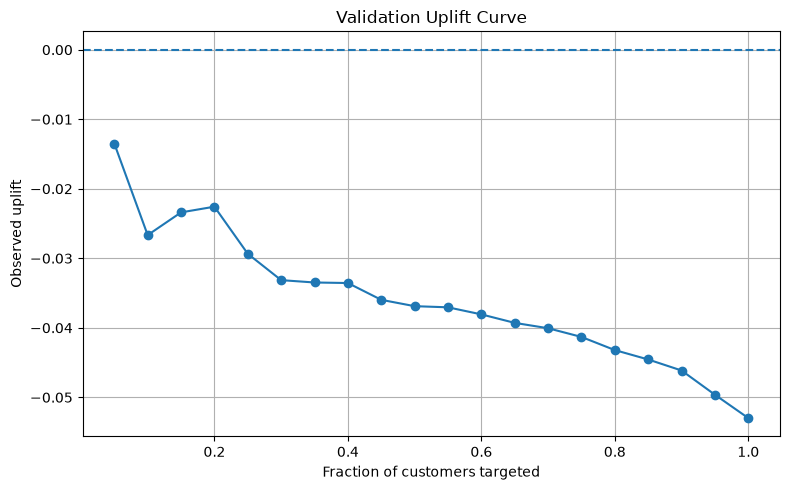

In [73]:
# ============================================================
# 11.7 PLOT UPLIFT CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    uplift_val["fraction"],
    uplift_val["uplift"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Fraction of customers targeted"
)

plt.ylabel(
    "Observed uplift"
)

plt.title(
    "Validation Uplift Curve"
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [74]:
# ============================================================
# 11.8 FINAL TEST UPLIFT
# ============================================================

uplift_test = calculate_uplift_curve(
    Y_test,
    T_test,
    tau_test
)

display(
    uplift_test
)

,fraction,uplift
0,0.05,-0.003100
1,0.10,0.004580
2,0.15,0.003935
3,0.20,0.006818
4,0.25,0.003482
5,0.30,0.003311
6,0.35,0.000210
7,0.40,-0.000825
8,0.45,-0.003811
9,0.50,-0.007177


# 12. Promotion Policy

The estimated treatment effect is translated into a promotion decision.

A customer is considered for promotion only when the estimated incremental
effect is sufficiently positive.

The no-promotion action remains available as the baseline decision.

In [75]:
# ============================================================
# 12.1 POLICY DATASET
# ============================================================

# Giữ nguyên CATE/uplift estimates hiện tại
policy = pd.DataFrame({
    "mu0_hat": np.asarray(mu0_test),
    "mu1_hat": np.asarray(mu1_test),
    "tau_hat": np.asarray(tau_test),
    "actual_treatment": np.asarray(T_test),
    "actual_outcome": np.asarray(Y_test)
})

# Promotion decision dựa trên estimated uplift
policy["recommendation"] = np.where(
    policy["tau_hat"] >= CONFIG["tau_threshold"],
    "PROMOTE",
    "DO NOT PROMOTE"
)

print("=== POLICY DATASET ===")

display(
    policy.head(20)
)

=== POLICY DATASET ===


,mu0_hat,mu1_hat,tau_hat,actual_treatment,actual_outcome,recommendation
0,0.244673,0.210926,-0.033747,0,0,DO NOT PROMOTE
1,0.445115,0.354166,-0.090949,0,0,DO NOT PROMOTE
2,0.103656,0.182791,0.079135,0,1,PROMOTE
3,0.140972,0.179868,0.038897,0,1,DO NOT PROMOTE
4,0.362259,0.433953,0.071693,0,1,PROMOTE
5,0.135243,0.147599,0.012355,0,1,DO NOT PROMOTE
6,0.434156,0.461474,0.027319,0,0,DO NOT PROMOTE
7,0.350576,0.316825,-0.033751,0,1,DO NOT PROMOTE
8,0.187214,0.214563,0.027349,0,0,DO NOT PROMOTE
9,0.200522,0.212843,0.012321,0,0,DO NOT PROMOTE


In [76]:
# ============================================================
# 12.2 POLICY DISTRIBUTION
# ============================================================

print("=== POLICY DISTRIBUTION ===")

policy_distribution = (
    policy["recommendation"]
    .value_counts()
    .to_frame("count")
)

policy_distribution["rate"] = (
    policy_distribution["count"]
    / len(policy)
).round(4)

display(
    policy_distribution
)

=== POLICY DISTRIBUTION ===


,count,rate
recommendation,,
DO NOT PROMOTE,960738,0.8554
PROMOTE,162383,0.1446


In [77]:
# ============================================================
# 12.3 WHAT-IF DISCOUNT SIMULATION
# ============================================================

# Six candidate promotion levels
discount_levels = np.array([
    0.00,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25
])

discount_results = []

# ------------------------------------------------------------
# Base price
# ------------------------------------------------------------
# Nếu dataset/pipeline hiện tại có price_test thì dùng nó.
# Nếu chưa có, code sẽ báo rõ để không âm thầm dùng sai biến.
if "price_test" in globals():

    base_price = np.asarray(price_test)

elif "X_test_price" in globals():

    base_price = np.asarray(X_test_price)

else:

    print(
        "WARNING: Không tìm thấy price_test."
    )

    print(
        "Cell này cần biến giá sản phẩm tương ứng với X_test."
    )

    base_price = None


# ------------------------------------------------------------
# Expected profit for each discount level
# ------------------------------------------------------------

if base_price is not None:

    base_price = np.asarray(base_price).reshape(-1)

    if len(base_price) != len(policy):

        raise ValueError(
            f"price_test có {len(base_price)} dòng "
            f"nhưng policy có {len(policy)} dòng."
        )

    for discount in discount_levels:

        discounted_price = (
            base_price * (1 - discount)
        )

        # Expected incremental value
        #
        # tau_hat = estimated treatment effect
        #
        # Here we use uplift as the estimated incremental
        # purchase probability and multiply it by the
        # discounted product value.
        expected_profit = (
            policy["tau_hat"].to_numpy()
            * discounted_price
        )

        discount_results.append({

            "discount": discount,

            "discount_percent": (
                discount * 100
            ),

            "mean_expected_profit":
                expected_profit.mean(),

            "median_expected_profit":
                np.median(expected_profit),

            "positive_profit_rate":
                (
                    expected_profit > 0
                ).mean(),

            "n_positive":
                (
                    expected_profit > 0
                ).sum()
        })


    discount_simulation = pd.DataFrame(
        discount_results
    )

    discount_simulation[
        [
            "mean_expected_profit",
            "median_expected_profit",
            "positive_profit_rate"
        ]
    ] = (
        discount_simulation[
            [
                "mean_expected_profit",
                "median_expected_profit",
                "positive_profit_rate"
            ]
        ].round(4)
    )

    print(
        "=== WHAT-IF DISCOUNT SIMULATION ==="
    )

    display(
        discount_simulation
    )

=== WHAT-IF DISCOUNT SIMULATION ===


,discount,discount_percent,mean_expected_profit,median_expected_profit,positive_profit_rate,n_positive
0,0.00,0.0,-0.2138,-0.0819,0.3157,354606
1,0.05,5.0,-0.2031,-0.0778,0.3157,354606
2,0.10,10.0,-0.1924,-0.0737,0.3157,354606
3,0.15,15.0,-0.1817,-0.0696,0.3157,354606
4,0.20,20.0,-0.1710,-0.0655,0.3157,354606
5,0.25,25.0,-0.1604,-0.0614,0.3157,354606


In [78]:
# ============================================================
# 12.4 OPTIMAL DISCOUNT POLICY
# ============================================================

if (
    "discount_simulation" in globals()
    and len(discount_simulation) > 0
):

    # Discount producing the highest expected profit
    best_row = (
        discount_simulation
        .loc[
            discount_simulation[
                "mean_expected_profit"
            ].idxmax()
        ]
    )

    best_discount = (
        best_row["discount"]
    )

    best_discount_percent = (
        best_row["discount_percent"]
    )

    best_expected_profit = (
        best_row["mean_expected_profit"]
    )

    print(
        "=== OPTIMAL DISCOUNT POLICY ==="
    )

    print(
        f"Recommended discount: "
        f"{best_discount_percent:.0f}%"
    )

    print(
        f"Mean expected profit: "
        f"{best_expected_profit:.4f}"
    )

    # --------------------------------------------------------
    # Case-level recommendation
    # --------------------------------------------------------

    policy["recommended_discount"] = (
        best_discount
    )

    policy["recommended_discount_percent"] = (
        best_discount_percent
    )

    display(
        policy[
            [
                "mu0_hat",
                "mu1_hat",
                "tau_hat",
                "recommendation",
                "recommended_discount_percent"
            ]
        ].head(20)
    )

=== OPTIMAL DISCOUNT POLICY ===
Recommended discount: 25%
Mean expected profit: -0.1604


,mu0_hat,mu1_hat,tau_hat,recommendation,recommended_discount_percent
0,0.244673,0.210926,-0.033747,DO NOT PROMOTE,25.0
1,0.445115,0.354166,-0.090949,DO NOT PROMOTE,25.0
2,0.103656,0.182791,0.079135,PROMOTE,25.0
3,0.140972,0.179868,0.038897,DO NOT PROMOTE,25.0
4,0.362259,0.433953,0.071693,PROMOTE,25.0
5,0.135243,0.147599,0.012355,DO NOT PROMOTE,25.0
6,0.434156,0.461474,0.027319,DO NOT PROMOTE,25.0
7,0.350576,0.316825,-0.033751,DO NOT PROMOTE,25.0
8,0.187214,0.214563,0.027349,DO NOT PROMOTE,25.0
9,0.200522,0.212843,0.012321,DO NOT PROMOTE,25.0


# 13. Explainability

SHAP is used to examine which observable model inputs are associated with
the treatment-effect estimation.

Latent GRU dimensions are treated as representation variables rather than
direct business rules.

In [79]:
# ============================================================
# IMPORT FOR MULTI-SEED VALIDATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

print("train_test_split imported successfully.")

train_test_split imported successfully.


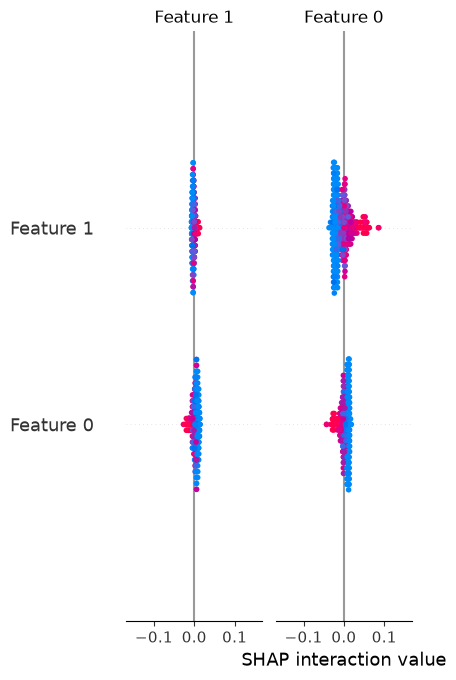

In [80]:
# ============================================================
# 13.1 SHAP
# ============================================================

if HAS_SHAP:

    explainer = shap.TreeExplainer(
        treatment_model
    )

    sample_n = min(
        500,
        len(X_test)
    )

    shap_values = (
        explainer
        .shap_values(
            X_test[:sample_n]
        )
    )

    shap.summary_plot(
        shap_values,
        X_test[:sample_n],
        show=True
    )

else:

    print(
        "SHAP unavailable."
    )

In [81]:
# ============================================================
# 13.2.0 DEFINE CATE TRAINING FUNCTION
# ============================================================

def train_cate_models(
    X_train,
    T_train,
    Y_train,
    X_test
):
    # Treated branch: μ1(X)
    treated_mask = (T_train == 1)

    model_treated = LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        class_weight="balanced"
    )

    model_treated.fit(
        X_train[treated_mask],
        Y_train[treated_mask]
    )

    # Control branch: μ0(X)
    control_mask = (T_train == 0)

    model_control = LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        class_weight="balanced"
    )

    model_control.fit(
        X_train[control_mask],
        Y_train[control_mask]
    )

    # Potential outcomes
    mu1_hat = model_treated.predict_proba(
        X_test
    )[:, 1]

    mu0_hat = model_control.predict_proba(
        X_test
    )[:, 1]

    return (
        model_treated,
        model_control,
        mu1_hat,
        mu0_hat
    )

print("train_cate_models() defined successfully.")

train_cate_models() defined successfully.


In [82]:
# ============================================================
# 13.2 DEFINE MULTI-SEED VALIDATION
# ============================================================

def validate_cate_multi_seed(
    X,
    T,
    Y,
    n_seeds=5,
    test_size=0.2
):

    results = []

    for seed in range(n_seeds):

        print(f"\nSeed {seed + 1}/{n_seeds}")

        # ----------------------------------------------------
        # Re-split data
        # ----------------------------------------------------

        train_idx, test_idx = train_test_split(
            np.arange(len(X)),
            test_size=test_size,
            random_state=seed,
            stratify=Y
        )

        # ----------------------------------------------------
        # Support both pandas DataFrame and NumPy array
        # ----------------------------------------------------

        if hasattr(X, "iloc"):

            X_train_seed = (
                X.iloc[train_idx]
                .reset_index(drop=True)
            )

            X_test_seed = (
                X.iloc[test_idx]
                .reset_index(drop=True)
            )

        else:

            X_train_seed = X[train_idx]

            X_test_seed = X[test_idx]

        # ----------------------------------------------------
        # Treatment / outcome
        # ----------------------------------------------------

        T_train_seed = T[train_idx]
        Y_train_seed = Y[train_idx]

        # ----------------------------------------------------
        # Train CATE models
        # ----------------------------------------------------

        _, _, mu1_seed, mu0_seed = train_cate_models(
            X_train_seed,
            T_train_seed,
            Y_train_seed,
            X_test_seed
        )

        # ----------------------------------------------------
        # Estimated treatment effect
        # ----------------------------------------------------

        tau_seed = mu1_seed - mu0_seed

        # ----------------------------------------------------
        # Store results
        # ----------------------------------------------------

        results.append({

            "seed": seed,

            "mean_mu1":
                mu1_seed.mean(),

            "mean_mu0":
                mu0_seed.mean(),

            "mean_tau":
                tau_seed.mean(),

            "std_tau":
                tau_seed.std(),

            "positive_tau_rate":
                (tau_seed > 0).mean()

        })

    return pd.DataFrame(results)

In [83]:
# ============================================================
# 13.3 RUN MULTI-SEED VALIDATION
# ============================================================

validation_results = validate_cate_multi_seed(
    X,
    T,
    Y,
    n_seeds=CONFIG["n_seeds"],
    test_size=CONFIG["test_ratio"]
)

print("\n=== MULTI-SEED CATE VALIDATION ===")

display(
    validation_results
)


Seed 1/5

Seed 2/5

Seed 3/5

Seed 4/5

Seed 5/5

=== MULTI-SEED CATE VALIDATION ===


,seed,mean_mu1,mean_mu0,mean_tau,std_tau,positive_tau_rate
0,0,0.413808,0.488728,-0.074920,0.053142,0.074044
1,1,0.411845,0.488677,-0.076832,0.052804,0.073177
2,2,0.413034,0.489090,-0.076056,0.052046,0.070827
3,3,0.412902,0.489345,-0.076443,0.051667,0.068890
4,4,0.412896,0.488381,-0.075485,0.053925,0.079366


# 14. Model Evaluation and Comparison

This stage evaluates the predictive performance of the candidate models
and compares their ability to discriminate between purchase and
non-purchase outcomes.

The evaluated models are:

- Logistic Regression
- LightGBM
- GRU

The comparison is performed at the model level using validation and test
metrics rather than evaluating individual customer cases.

For the causal component, treatment-effect stability is evaluated
separately using the multi-seed CATE validation results.

In [84]:
# ============================================================
# 14.0 INDEX FOR MODEL COMPARISON
# ============================================================

train_indices = order[:val_start]

val_indices = order[val_start:test_start]

test_indices = order[test_start:]

print("Train indices:", len(train_indices))
print("Validation indices:", len(val_indices))
print("Test indices:", len(test_indices))

Train indices: 3593987
Validation indices: 898497
Test indices: 1123121


In [88]:
# ============================================================
# 14.1 PREDICTIVE MODEL COMPARISON
# ============================================================

# Reconstruct indices explicitly
train_indices = order[:val_start]
val_indices = order[val_start:test_start]
test_indices = order[test_start:]

model_results = []


# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

model_results.append({
    "model": "Logistic Regression",

    "validation_auc": roc_auc_score(
        Y_val,
        val_lr
    ),

    "test_auc": roc_auc_score(
        Y_test,
        test_lr
    )
})


# ------------------------------------------------------------
# LightGBM
# ------------------------------------------------------------

if HAS_LGB:

    model_results.append({
        "model": "LightGBM",

        "validation_auc": roc_auc_score(
            Y_val,
            val_lgb
        ),

        "test_auc": roc_auc_score(
            Y_test,
            test_lgb
        )
    })


# ------------------------------------------------------------
# GRU
# ------------------------------------------------------------

if HAS_TF:

    # X_seq = NumPy array
    # X_static = Pandas DataFrame
    # Therefore:
    # - X_seq[index]           -> positional indexing
    # - X_static.iloc[index]   -> positional row indexing

    gru_val_pred = (
        gru_predictor.predict(
            {
                "event_sequence": X_seq[val_indices],

                "static_features":
                    X_static.iloc[val_indices].to_numpy()
            },
            verbose=0
        )
        .ravel()
    )

    gru_test_pred = (
        gru_predictor.predict(
            {
                "event_sequence": X_seq[test_indices],

                "static_features":
                    X_static.iloc[test_indices].to_numpy()
            },
            verbose=0
        )
        .ravel()
    )

    model_results.append({
        "model": "GRU",

        "validation_auc": roc_auc_score(
            Y_val,
            gru_val_pred
        ),

        "test_auc": roc_auc_score(
            Y_test,
            gru_test_pred
        )
    })


# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

model_comparison = pd.DataFrame(
    model_results
)

display(
    model_comparison
)

,model,validation_auc,test_auc
0,Logistic Regression,0.618930,0.638725
1,LightGBM,0.659495,0.674771
2,GRU,0.646684,0.663352


In [89]:
# ============================================================
# 14.2 MODEL COMPARISON SUMMARY
# ============================================================

model_comparison_display = (
    model_comparison
    .copy()
)

model_comparison_display[
    "validation_auc"
] = model_comparison_display[
    "validation_auc"
].round(4)

model_comparison_display[
    "test_auc"
] = model_comparison_display[
    "test_auc"
].round(4)

model_comparison_display[
    "auc_gap"
] = (
    model_comparison_display[
        "validation_auc"
    ]
    -
    model_comparison_display[
        "test_auc"
    ]
).abs().round(4)

display(
    model_comparison_display
)

,model,validation_auc,test_auc,auc_gap
0,Logistic Regression,0.6189,0.6387,0.0198
1,LightGBM,0.6595,0.6748,0.0153
2,GRU,0.6467,0.6634,0.0167


In [90]:
# ============================================================
# 14.3 BEST PREDICTIVE MODEL
# ============================================================

best_model_row = (
    model_comparison
    .loc[
        model_comparison["test_auc"].idxmax()
    ]
)

print(
    "Best predictive model based on test AUC:"
)

print(
    best_model_row["model"]
)

print(
    f"Test AUC: "
    f"{best_model_row['test_auc']:.4f}"
)

Best predictive model based on test AUC:
LightGBM
Test AUC: 0.6748


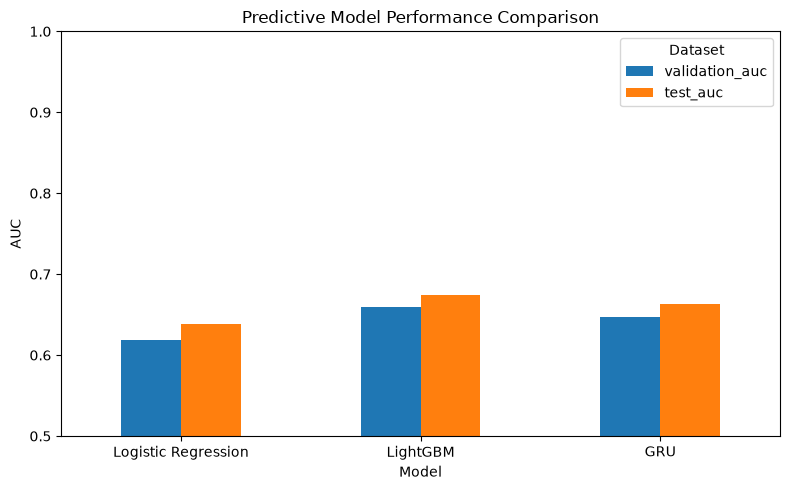

In [91]:
# ============================================================
# 14.3.1 MODEL PERFORMANCE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plot_df = model_comparison.copy()

plot_df = plot_df.set_index("model")[
    ["validation_auc", "test_auc"]
]

plot_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("AUC")
plt.xlabel("Model")
plt.title("Predictive Model Performance Comparison")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

In [92]:
# ============================================================
# 14.3.2 CLASSIFICATION METRICS COMPARISON
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metrics_results = []

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

lr_pred_class = (test_lr >= 0.5).astype(int)

metrics_results.append({
    "model": "Logistic Regression",
    "accuracy": accuracy_score(Y_test, lr_pred_class),
    "precision": precision_score(Y_test, lr_pred_class, zero_division=0),
    "recall": recall_score(Y_test, lr_pred_class, zero_division=0),
    "f1": f1_score(Y_test, lr_pred_class, zero_division=0)
})

# ------------------------------------------------------------
# LightGBM
# ------------------------------------------------------------

if HAS_LGB:

    lgb_pred_class = (test_lgb >= 0.5).astype(int)

    metrics_results.append({
        "model": "LightGBM",
        "accuracy": accuracy_score(Y_test, lgb_pred_class),
        "precision": precision_score(Y_test, lgb_pred_class, zero_division=0),
        "recall": recall_score(Y_test, lgb_pred_class, zero_division=0),
        "f1": f1_score(Y_test, lgb_pred_class, zero_division=0)
    })

# ------------------------------------------------------------
# GRU
# ------------------------------------------------------------

if HAS_TF:

    gru_pred_class = (gru_test_pred >= 0.5).astype(int)

    metrics_results.append({
        "model": "GRU",
        "accuracy": accuracy_score(Y_test, gru_pred_class),
        "precision": precision_score(Y_test, gru_pred_class, zero_division=0),
        "recall": recall_score(Y_test, gru_pred_class, zero_division=0),
        "f1": f1_score(Y_test, gru_pred_class, zero_division=0)
    })

classification_comparison = pd.DataFrame(metrics_results)

classification_comparison[
    ["accuracy", "precision", "recall", "f1"]
] = classification_comparison[
    ["accuracy", "precision", "recall", "f1"]
].round(4)

display(classification_comparison)

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.6674,0.2404,0.4775,0.3198
1,LightGBM,0.6332,0.2481,0.6105,0.3528
2,GRU,0.6003,0.2356,0.6420,0.3447


### Interpretation

The predictive models are compared using validation AUC and test AUC.

Test AUC is used as the primary metric for ranking predictive
discrimination, while the gap between validation and test AUC is
examined as an indicator of potential overfitting.

A higher test AUC indicates better discrimination between purchase and
non-purchase outcomes. However, predictive performance alone does not
determine the quality of a causal targeting model. Therefore, treatment
effect stability is evaluated separately in the next section.

In [93]:
# ============================================================
# 14.4 CATE / UPLIFT STABILITY EVALUATION
# ============================================================

cate_summary = pd.DataFrame({
    "metric": [
        "Mean estimated uplift",
        "Mean uplift standard deviation",
        "Positive uplift rate"
    ],
    "value": [
        validation_results["mean_tau"].mean(),
        validation_results["std_tau"].mean(),
        validation_results["positive_tau_rate"].mean()
    ]
})

cate_summary["value"] = (
    cate_summary["value"]
    .round(4)
)

display(
    cate_summary
)

,metric,value
0,Mean estimated uplift,-0.0759
1,Mean uplift standard deviation,0.0527
2,Positive uplift rate,0.0733


In [94]:
# ============================================================
# 14.5 MULTI-SEED CATE RESULTS
# ============================================================

display(
    validation_results
)

,seed,mean_mu1,mean_mu0,mean_tau,std_tau,positive_tau_rate
0,0,0.413808,0.488728,-0.074920,0.053142,0.074044
1,1,0.411845,0.488677,-0.076832,0.052804,0.073177
2,2,0.413034,0.489090,-0.076056,0.052046,0.070827
3,3,0.412902,0.489345,-0.076443,0.051667,0.068890
4,4,0.412896,0.488381,-0.075485,0.053925,0.079366


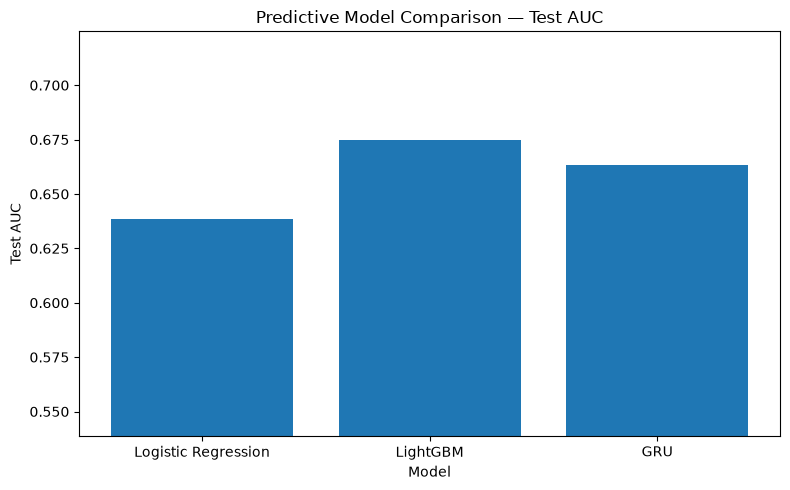

In [95]:
# ============================================================
# 14.6 TEST AUC COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["model"],
    model_comparison["test_auc"]
)

plt.ylabel("Test AUC")
plt.xlabel("Model")
plt.title("Predictive Model Comparison — Test AUC")

plt.ylim(
    max(
        0,
        model_comparison["test_auc"].min() - 0.1
    ),
    min(
        1,
        model_comparison["test_auc"].max() + 0.05
    )
)

plt.tight_layout()
plt.show()

### Model Evaluation Summary

The predictive models are benchmarked using validation and test AUC.

The model with the highest test AUC provides the strongest predictive
discrimination for purchase outcomes.

However, the final promotion-targeting decision is not based solely on
predictive AUC. The causal component is evaluated through the stability
of estimated treatment effects across multiple random seeds.

Therefore, model selection considers both predictive performance and
the stability of estimated treatment effects.

In [96]:
# ============================================================
# 15. FINAL UPLIFT RESULTS
# ============================================================

final_results = policy.copy()

final_results["absolute_uplift"] = (
    final_results["tau_hat"].abs()
)

final_results = (
    final_results
    .sort_values(
        "tau_hat",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    final_results.head(20)
)

,mu0_hat,mu1_hat,tau_hat,actual_treatment,actual_outcome,recommendation,recommended_discount,recommended_discount_percent,absolute_uplift
0,0.046821,0.586641,0.539821,0,0,PROMOTE,0.25,25.0,0.539821
1,0.052196,0.585047,0.532852,0,0,PROMOTE,0.25,25.0,0.532852
2,0.108015,0.640823,0.532807,0,0,PROMOTE,0.25,25.0,0.532807
3,0.059122,0.587499,0.528377,0,0,PROMOTE,0.25,25.0,0.528377
4,0.107965,0.635624,0.527659,0,0,PROMOTE,0.25,25.0,0.527659
5,0.109902,0.637065,0.527164,0,0,PROMOTE,0.25,25.0,0.527164
6,0.100839,0.626327,0.525488,0,0,PROMOTE,0.25,25.0,0.525488
7,0.050675,0.575421,0.524745,0,0,PROMOTE,0.25,25.0,0.524745
8,0.043188,0.567787,0.524599,0,0,PROMOTE,0.25,25.0,0.524599
9,0.059437,0.582093,0.522656,0,0,PROMOTE,0.25,25.0,0.522656


In [97]:
# ============================================================
# 15.1 EXPORT RESULTS
# ============================================================

final_results.to_csv(
    "final_uplift_results.csv",
    index=False
)

daily.to_csv(
    "daily_event_discovery.csv"
)

model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print(
    "Results exported successfully."
)

Results exported successfully.


# 16. Conclusion

The revised pipeline moves from purchase propensity prediction to
incremental promotion-effect estimation.

The analysis proceeds through:

1. real-data preprocessing
2. data-driven temporal event discovery
3. session and decision-point construction
4. treatment and outcome definition
5. behavioral representation learning
6. predictive benchmarking
7. uplift/CATE estimation
8. temporal validation
9. explainability
10. promotion policy generation

The main analytical output is the estimated treatment effect:

\[
\hat{\tau}(X)
=
\hat{\mu}_1(X)
-
\hat{\mu}_0(X)
\]

A positive value indicates that promotion is estimated to increase the
probability of the selected outcome relative to the no-promotion condition.

Therefore, the final promotion decision is based on incremental value
rather than purchase propensity alone.